# Import libraries

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Read data

In [77]:
file_path='D:/Learning/MachineLearningForSignalProcessing/LinearRegression/housing.csv'
data = pd.read_csv(file_path)

In [79]:
data.sample(20)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
8041,-118.16,33.84,36.0,2444.0,432.0,1199.0,424.0,4.1538,218800.0,<1H OCEAN
6936,-118.09,34.00,36.0,1722.0,353.0,1174.0,335.0,3.0450,160600.0,<1H OCEAN
16883,-122.38,37.59,44.0,2089.0,348.0,837.0,317.0,4.6628,459200.0,NEAR OCEAN
18609,-122.04,37.12,30.0,1427.0,311.0,686.0,251.0,4.0781,154500.0,NEAR OCEAN
17614,-121.92,37.29,32.0,1260.0,199.0,560.0,207.0,6.5858,346700.0,<1H OCEAN
9288,-122.41,38.07,20.0,4536.0,708.0,1812.0,701.0,6.0433,435900.0,NEAR BAY
7990,-118.18,33.86,39.0,2925.0,732.0,1702.0,642.0,2.3750,160800.0,<1H OCEAN
570,-122.24,37.72,5.0,18634.0,2885.0,7427.0,2718.0,7.6110,350700.0,NEAR BAY
2898,-119.01,35.38,52.0,114.0,26.0,158.0,26.0,1.0750,67500.0,INLAND
4795,-118.35,34.03,49.0,2334.0,530.0,1334.0,447.0,1.8900,124000.0,<1H OCEAN


In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [83]:
data.describe().round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


# Data cleaning

## Check duplicated data

In [87]:
data.duplicated().sum()

0

## Check Missing value

In [90]:
data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## Fill missing value

In [93]:
data.total_bedrooms.value_counts().iloc[:50]

total_bedrooms
280.0    55
331.0    51
345.0    50
343.0    49
393.0    49
328.0    48
348.0    48
394.0    48
272.0    47
309.0    47
314.0    46
322.0    46
399.0    46
295.0    46
317.0    46
313.0    45
290.0    45
346.0    45
340.0    45
287.0    45
388.0    45
284.0    45
291.0    45
294.0    44
269.0    44
390.0    44
312.0    44
460.0    44
300.0    44
361.0    44
365.0    44
398.0    43
335.0    43
416.0    43
254.0    43
289.0    43
369.0    43
373.0    43
428.0    43
292.0    42
339.0    42
315.0    42
458.0    42
360.0    42
308.0    42
282.0    42
358.0    41
325.0    41
410.0    41
347.0    41
Name: count, dtype: int64

In [95]:
data.total_bedrooms.median()

435.0

In [97]:
data.total_bedrooms.fillna(data.total_bedrooms.median(),inplace=True)

In [99]:
data.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

# Preprocessing Data

In [102]:
data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

<Axes: xlabel='ocean_proximity', ylabel='Count'>

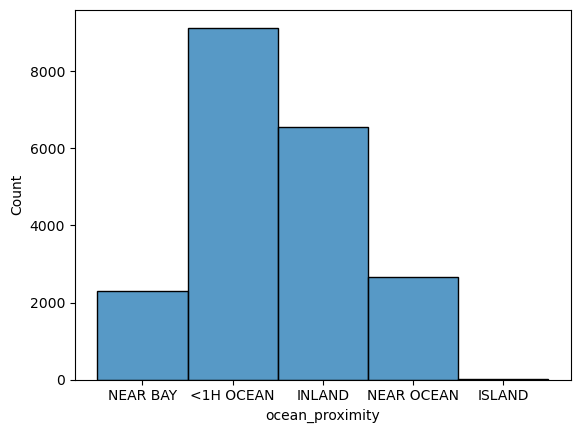

In [104]:
sns.histplot(data.ocean_proximity)

In [106]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [108]:
data.ocean_proximity.replace({'<1H OCEAN':0, 'INLAND':1, 'NEAR OCEAN': 2, 'NEAR BAY':3, 'ISLAND':4},inplace= True)

In [110]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1


In [112]:
data[['total_rooms','total_bedrooms']].value_counts()

total_rooms  total_bedrooms
1440.0       267.0             3
40.0         10.0              3
1387.0       236.0             3
1864.0       331.0             3
102.0        17.0              3
                              ..
1678.0       606.0             1
             514.0             1
             386.0             1
             369.0             1
39320.0      6210.0            1
Name: count, Length: 20460, dtype: int64

In [114]:
data[['total_rooms','median_house_value']].groupby(data['total_bedrooms']).value_counts().sort_values(ascending=False)[0:20]

total_bedrooms  total_rooms  median_house_value
6.0             24.0         67500.0               2
3.0             18.0         275000.0              2
1.0             8.0          500001.0              1
556.0           1790.0       181300.0              1
                2315.0       147900.0              1
                2188.0       136800.0              1
                1926.0       123200.0              1
                1871.0       164400.0              1
                1853.0       248100.0              1
                1852.0       152500.0              1
                1802.0       146900.0              1
                1672.0       129200.0              1
                2447.0       85500.0               1
                1270.0       170800.0              1
555.0           3742.0       285400.0              1
                3420.0       173800.0              1
                3306.0       319900.0              1
                3225.0       173300.0              

In [116]:
data[['total_rooms','median_house_value']].value_counts().sort_values(ascending=False)[0:20]

total_rooms  median_house_value
2170.0       500001.0              4
2089.0       500001.0              3
1721.0       500001.0              3
2492.0       500001.0              3
2718.0       500001.0              3
2398.0       500001.0              3
2665.0       500001.0              3
3095.0       500001.0              3
60.0         67500.0               3
2959.0       500001.0              2
1590.0       500001.0              2
2501.0       500001.0              2
2142.0       325000.0              2
2629.0       500001.0              2
1777.0       500001.0              2
1366.0       150000.0              2
24.0         67500.0               2
2075.0       500001.0              2
2040.0       500001.0              2
1151.0       113600.0              2
Name: count, dtype: int64

In [118]:
data[['total_rooms','median_house_value']].value_counts().sort_values(ascending=False)[0:15]

total_rooms  median_house_value
2170.0       500001.0              4
2089.0       500001.0              3
1721.0       500001.0              3
2492.0       500001.0              3
2718.0       500001.0              3
2398.0       500001.0              3
2665.0       500001.0              3
3095.0       500001.0              3
60.0         67500.0               3
2959.0       500001.0              2
1590.0       500001.0              2
2501.0       500001.0              2
2142.0       325000.0              2
2629.0       500001.0              2
1777.0       500001.0              2
Name: count, dtype: int64

## Relation between total_rooms and housing_median_age

In [121]:
data[['total_rooms','total_bedrooms','housing_median_age']].value_counts().sort_values(ascending=False)

total_rooms  total_bedrooms  housing_median_age
2264.0       439.0           52.0                  2
24.0         6.0             52.0                  2
48.0         8.0             26.0                  2
2205.0       453.0           33.0                  2
1511.0       274.0           35.0                  2
                                                  ..
32627.0      6445.0          11.0                  1
37937.0      5471.0          4.0                   1
27870.0      5027.0          5.0                   1
18767.0      3032.0          4.0                   1
39320.0      6210.0          3.0                   1
Name: count, Length: 20633, dtype: int64

In [123]:
dt=data[['total_rooms','housing_median_age']].sort_values(ascending=True,by='total_rooms')

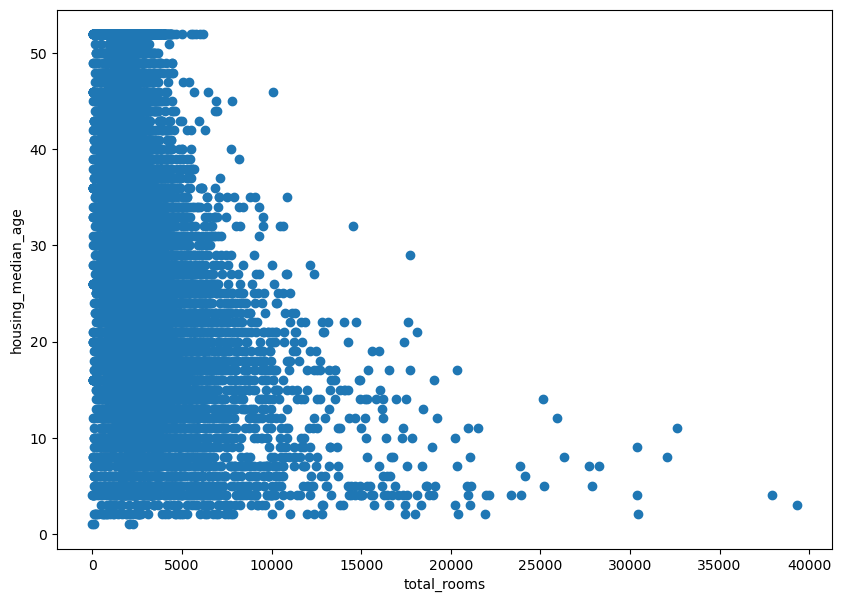

In [125]:
plt.figure(figsize=(10,7))
plt.scatter(x=dt['total_rooms'],y=dt['housing_median_age'])
plt.xlabel('total_rooms')
plt.ylabel('housing_median_age')
plt.show()

## Relation longitude, latitude and median_house_value, ocean_proximity 

In [128]:
data[['longitude','median_house_value','ocean_proximity']].value_counts().sort_values(ascending=False)

longitude  median_house_value  ocean_proximity
-118.40    500001.0            0                  29
-118.43    500001.0            0                  23
-118.41    500001.0            0                  23
-122.44    500001.0            3                  20
-118.42    500001.0            0                  17
                                                  ..
-117.08    137500.0            0                   1
           137900.0            0                   1
           139800.0            2                   1
           140300.0            2                   1
-114.31    66900.0             1                   1
Name: count, Length: 19462, dtype: int64

In [130]:
data[['latitude','median_house_value','ocean_proximity']].value_counts().sort_values(ascending=False)

latitude  median_house_value  ocean_proximity
34.06     500001.0            0                  45
37.79     500001.0            3                  33
34.07     500001.0            0                  30
37.80     500001.0            3                  28
34.05     500001.0            0                  27
                                                 ..
40.62     107000.0            2                   1
40.65     118300.0            1                   1
40.66     75800.0             1                   1
          92200.0             1                   1
41.95     122400.0            2                   1
Name: count, Length: 19375, dtype: int64

In [132]:
data[['longitude','latitude','median_house_value','ocean_proximity']].value_counts().sort_values(ascending=False)

longitude  latitude  median_house_value  ocean_proximity
-122.44    37.80     500001.0            3                  9
           37.79     500001.0            3                  8
-122.43    37.79     500001.0            3                  7
-122.42    37.80     500001.0            3                  7
-122.41    37.80     500001.0            3                  6
                                                           ..
-116.41    33.74     168800.0            1                  1
                     177800.0            1                  1
-116.40    33.78     259200.0            1                  1
           34.09     97800.0             1                  1
-114.31    34.19     66900.0             1                  1
Name: count, Length: 20315, dtype: int64

In [134]:
data[['median_house_value']].groupby(data['ocean_proximity']).value_counts().sort_values(ascending=False)[0:20]

ocean_proximity  median_house_value
0                500001.0              532
2                500001.0              212
3                500001.0              194
0                162500.0               55
1                112500.0               52
0                187500.0               48
1                137500.0               47
                 87500.0                47
0                137500.0               45
                 225000.0               43
                 350000.0               43
1                67500.0                34
                 162500.0               33
0                175000.0               33
1                100000.0               30
0                275000.0               30
                 150000.0               28
                 112500.0               27
1                500001.0               27
0                200000.0               25
Name: count, dtype: int64

In [136]:
data[['median_house_value','housing_median_age']].groupby(data['ocean_proximity']).value_counts().sort_values(ascending=False)[0:20]

ocean_proximity  median_house_value  housing_median_age
3                500001.0            52.0                  97
0                500001.0            52.0                  58
                                     36.0                  21
                                     35.0                  21
                                     34.0                  19
                                     37.0                  18
                                     31.0                  17
                                     27.0                  16
2                500001.0            52.0                  15
0                500001.0            25.0                  15
                                     33.0                  15
                                     45.0                  15
2                500001.0            34.0                  15
0                500001.0            28.0                  14
                                     42.0                  14
              

## Realtion between median_house_value and housing_median_age

In [139]:
data['median_house_value'].value_counts().sort_values(ascending=False).iloc[0:20]

median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
225000.0     92
350000.0     79
87500.0      78
275000.0     65
150000.0     64
175000.0     63
100000.0     62
125000.0     56
67500.0      55
250000.0     47
200000.0     46
118800.0     39
450000.0     37
156300.0     35
212500.0     33
Name: count, dtype: int64

In [141]:
data['housing_median_age'].groupby(data['median_house_value']).value_counts().iloc[0:20]

median_house_value  housing_median_age
14999.0             16.0                  1
                    19.0                  1
                    36.0                  1
                    52.0                  1
17500.0             39.0                  1
22500.0             52.0                  2
                    8.0                   1
                    33.0                  1
25000.0             21.0                  1
26600.0             34.0                  1
26900.0             46.0                  1
27500.0             17.0                  1
28300.0             29.0                  1
30000.0             23.0                  1
                    45.0                  1
32500.0             15.0                  1
                    20.0                  1
                    24.0                  1
                    52.0                  1
32900.0             14.0                  1
Name: count, dtype: int64

## Population data

In [144]:
data['population'].value_counts()

population
891.0     25
761.0     24
1227.0    24
1052.0    24
850.0     24
          ..
2141.0     1
5546.0     1
3186.0     1
3590.0     1
6912.0     1
Name: count, Length: 3888, dtype: int64

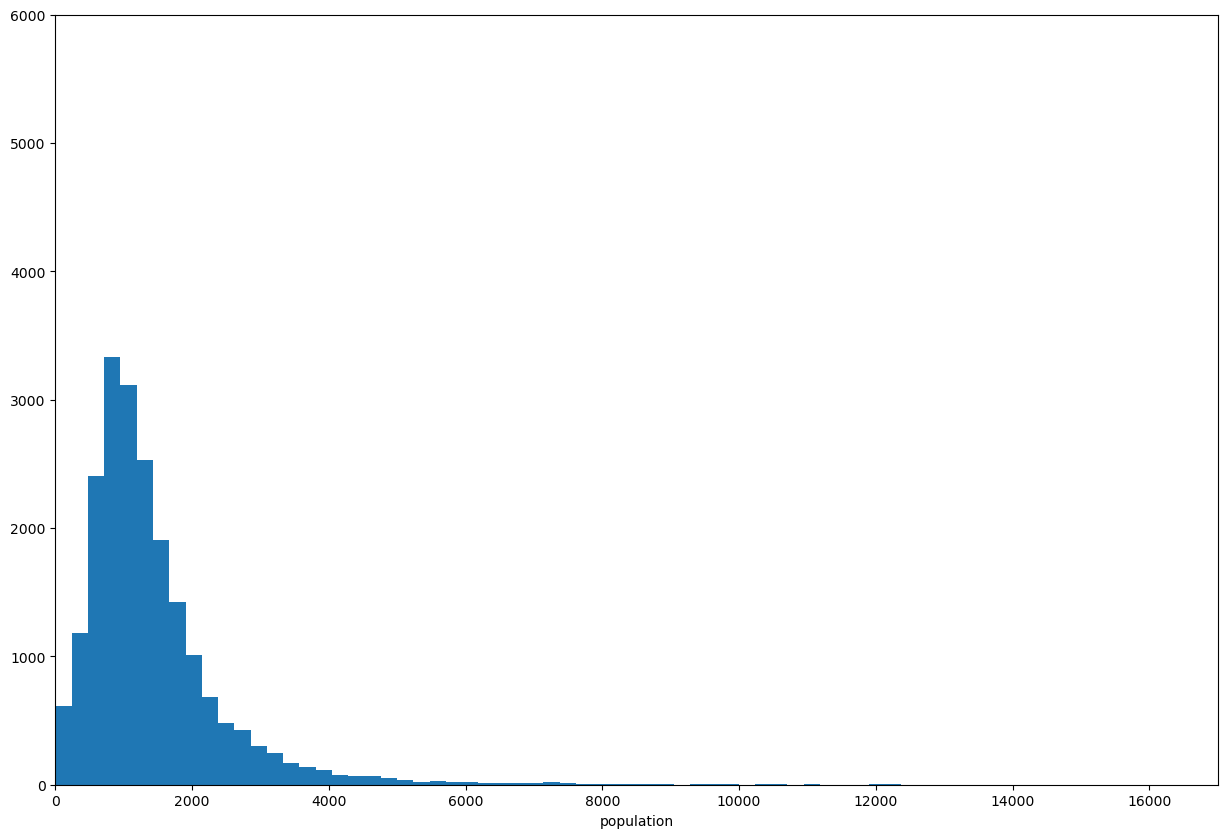

In [146]:
plt.figure(figsize=(15,10))
plt.hist(data['population'],bins=150)
plt.xlabel('population')
plt.xlim(0,17000)
plt.ylim(0,6000)
plt.show()

In [147]:
data[['population','households']].groupby(data['median_house_value']).value_counts().sort_values(ascending=False)

median_house_value  population  households
500001.0            39.0        14.0          2
                    410.0       171.0         2
225000.0            14.0        7.0           2
14999.0             18.0        8.0           1
230200.0            2037.0      727.0         1
                                             ..
141400.0            1767.0      628.0         1
                    1534.0      625.0         1
                    590.0       205.0         1
141300.0            2248.0      766.0         1
500001.0            7431.0      4930.0        1
Name: count, Length: 20637, dtype: int64

<Axes: >

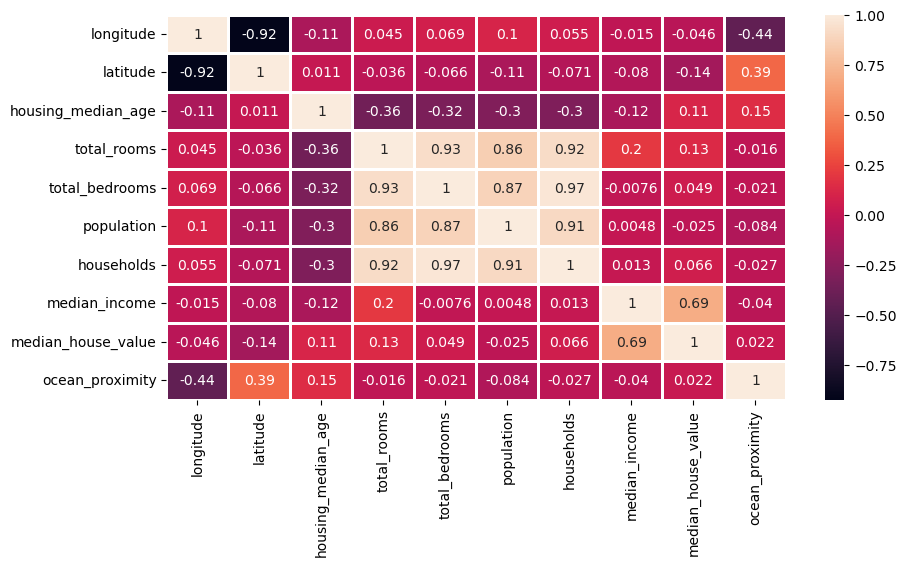

In [150]:
plt.figure(figsize=(10,5))
sns.heatmap(data.corr(),annot=True, linewidths=2)

## Relation between median_income and median_house_value

In [153]:
data[['median_house_value','median_income']].sort_values(ascending=True,by='median_income')

,median_house_value,median_income
4861,500001.0,0.4999
7125,162500.0,0.4999
6688,500001.0,0.4999
19800,56700.0,0.4999
6343,112500.0,0.4999
...,...,...
4605,500001.0,15.0001
4606,500001.0,15.0001
4626,500001.0,15.0001
8848,500001.0,15.0001


In [155]:
data['median_house_value'].groupby(data['median_income']).value_counts().sort_values(ascending=False)

median_income  median_house_value
15.0001        500001.0              46
2.6250         137500.0               3
               187500.0               3
2.3750         175000.0               3
7.5000         500001.0               3
                                     ..
2.8913         60900.0                1
2.8910         178100.0               1
2.8906         204900.0               1
               158300.0               1
15.0001        400000.0               1
Name: count, Length: 20532, dtype: int64

In [157]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [159]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [160]:
X_data = data.drop(['median_house_value'],axis=1)
y_label = data['median_house_value']

In [163]:
x_train,x_test,y_train,y_test = train_test_split(X_data,y_label,test_size=0.2,random_state=42)

In [165]:
def Regression_model(model):
    model.fit(x_train, y_train)
    train_data_accuracy = model.score(x_train,y_train)  # train data
    test_data_accuracy = model.score(x_test,y_test) #test data
    print('model name: ',model)
    print('accuracy of train data= ',train_data_accuracy)
    print('accuracy of test data= ',test_data_accuracy)

In [167]:
# Linear Regression model
model = LinearRegression()
Regression_model(model)

model name:  LinearRegression()
accuracy of train data=  0.640334144695327
accuracy of test data=  0.613374527046818


In [169]:
# RandomForestRegressor Model
model = RandomForestRegressor()
Regression_model(model)

model name:  RandomForestRegressor()
accuracy of train data=  0.9746848556966585
accuracy of test data=  0.809474746575314
